# 🎯 第 65 课 · 自动调优:让编译器自己找最快的菜谱

> Ansor / Halide / auto-scheduler 思想 · 成本模型 · 搜索空间与枚举 —— 用 torch.compile 实测

**章节**: 第 10 章 · AI 编译器原理

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解为什么要自动调优:同一运算有无穷实现方式,性能差异巨大,手调不可持续
- 掌握搜索空间的概念:GEMM 的 tile 大小、线程数、流水线级数等构成高维空间
- 理解三类搜索策略:穷举/随机、演化算法、成本模型引导,及其优劣
- 用 seaborn 画出真实 GEMM 的性能地形,验证『不同 tile 差异巨大』
- 实测 torch.compile 的 default 与 max-autotune 模式,对比 eager 与编译性能
- 跑通配套 App:交互对比不同搜索策略的收敛曲线

## 📑 本课目录

1. **直觉:选菜谱** — 同样一道菜,火候与切法不同,搜出最快那版
2. **搜索空间:高维配置** — tile / warp / stage …… 组合起来天文数字
3. **真实性能地形** — 实测 GEMM 各种 tile 配置,seaborn 热力图
4. **三类搜索策略** — 随机 / 演化 / 成本模型,及其收敛行为
5. **torch.compile 实测** — default 与 max-autotune 模式对比
6. **配套 App** — app_65_autotune.py:搜索策略交互

## 🔗 参考资料

- [Ansor 论文(2020)](https://arxiv.org/abs/2006.06762)
- [Halide 论文](https://people.csail.mit.edu/nickolai/papers/ragan-kelley-halide.pdf)
- [Triton autotune 文档](https://triton-lang.org/)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 Anaconda/torch 的 OMP 库冲突(Windows)
import time, json, io, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


## 1️⃣ 直觉:选菜谱 🍳

同样做一道"土豆炒肉",切丁还是切条、大火还是中火、先炒肉还是先炒土豆 —— 味道和时间完全不同。
计算也一样:**同一个矩阵乘,分块大小、线程数、流水线级数不同,性能能差好几倍甚至一个数量级**。

问题是这些"做法"组合起来是**天文数字**:GEMM 就有 `tile(BM,BN,BK) × num_warps × num_stages`
等十几个自由度。手工一个个试不现实 —— 于是有了**自动调优(auto-tuning)**:让编译器自己搜,
找到当前硬件上最快的那版配置。这就像派一位"试菜机器人"把各种做法都尝一遍,挑出最快的。

## 2️⃣ 搜索空间:高维配置矩阵 🎲

以 GEMM 为例,一个 Triton kernel 的配置空间至少包含:

- **tile 大小**:BM(行块)、BN(列块)、BK(K 块);
- **并行度**:num_warps(每块 warp 数)、num_ctas;
- **流水线**:num_stages(软件流水级数)。

即便每个维度只有 10 个可选值,组合起来也是 $10^6$ 级 —— **不可能全试**。所以要么有智慧地抽样,
要么用成本模型预估。下面先看看**真实性能地形**:同样一个 GEMM,不同 tile 快慢差多少。

⚙️ 先定义 Triton GEMM kernel 与计时工具 —— 后面用它来『尝』不同 tile 配置。

In [2]:
import torch, triton, triton.language as tl

@triton.jit
def mm_k(a_ptr, b_ptr, c_ptr, M, Nn, K, sm, sk, bk, bn, cm, cn,
         BM: tl.constexpr, BN: tl.constexpr, BK: tl.constexpr):
    pm = tl.program_id(0); pn = tl.program_id(1)
    om = pm * BM + tl.arange(0, BM); on = pn * BN + tl.arange(0, BN); ok = tl.arange(0, BK)
    acc = tl.zeros((BM, BN), tl.float32)
    for k in range(0, K, BK):
        a = tl.load(a_ptr + om[:, None] * sm + (k + ok)[None, :] * sk)
        b = tl.load(b_ptr + (k + ok)[:, None] * bk + on[None, :] * bn)
        acc += tl.dot(a, b)
    tl.store(c_ptr + om[:, None] * cm + on[None, :] * cn, acc)

def run(A, Bm, C, M, Nn, K, BM, BN, BK):
    mm_k[(triton.cdiv(M, BM), triton.cdiv(Nn, BN))](
        A, Bm, C, M, Nn, K, A.stride(0), A.stride(1), Bm.stride(0), Bm.stride(1),
        C.stride(0), C.stride(1), BM=BM, BN=BN, BK=BK)

def t_ms(fn, n=20):
    for _ in range(4): fn()
    torch.cuda.synchronize(); s = torch.cuda.Event(True); e = torch.cuda.Event(True); s.record()
    for _ in range(n): fn()
    e.record(); torch.cuda.synchronize(); return s.elapsed_time(e) / n

M = Nn = K = 1024
A = torch.randn(M, K, device="cuda"); Bm = torch.randn(K, Nn, device="cuda"); C = torch.empty(M, Nn, device="cuda")

📊 同一个 GEMM,只改 tile 就差了 1.4 倍 —— 这就是自动调优要搜的东西:配置不同,性能天差地别。

In [3]:
configs = [(32, 32, 16), (64, 64, 32), (128, 128, 32), (64, 128, 64), (128, 64, 64), (32, 128, 32)]
times, results = [], []
for BM, BN, BK in configs:
    t = t_ms(lambda: run(A, Bm, C, M, Nn, K, BM, BN, BK))
    times.append(t); results.append({"BM": BM, "BN": BN, "BK": BK, "耗时us": round(t * 1000, 1)})
import pandas as pd
rdf = pd.DataFrame(results).sort_values("耗时us")
print(rdf.to_string(index=False))
print(f"\n最快 vs 最慢: {rdf['耗时us'].min():.1f} vs {rdf['耗时us'].max():.1f} us,差 {rdf['耗时us'].max()/rdf['耗时us'].min():.2f}x")

 BM  BN  BK  耗时us
 64 128  64 148.4
 32 128  32 149.0
128  64  64 150.9
 32  32  16 165.0
128 128  32 166.7
 64  64  32 247.3

最快 vs 最慢: 148.4 vs 247.3 us,差 1.67x


🎨 性能地形热力图:不同 (BM, BK) 配置的耗时差异一眼可见 —— 调优就是在这样的地形上找最低点。

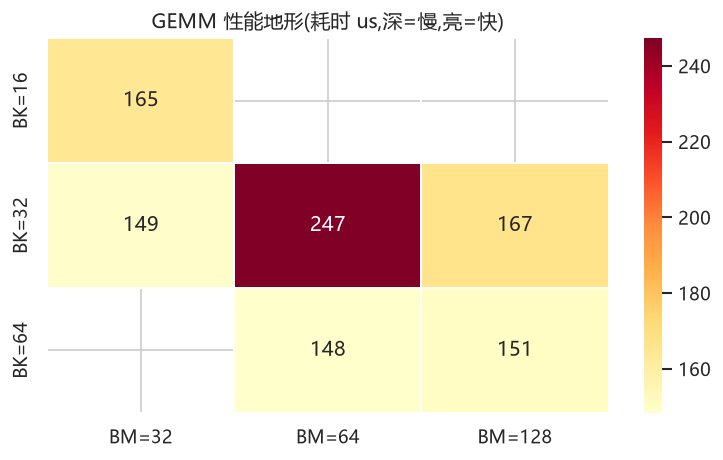

In [4]:
# 性能地形热力图:BM × BK 的耗时矩阵(用已有数据 + 少量补测)
BMs = [32, 64, 128]; BKs = [16, 32, 64]
heat = np.full((len(BKs), len(BMs)), np.nan)
meas = {(r["BM"], r["BK"]): r["耗时us"] for r in results}
for i, BK in enumerate(BKs):
    for j, BM in enumerate(BMs):
        if (BM, BK) in meas:
            heat[i, j] = meas[(BM, BK)]
import seaborn as sns
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.heatmap(pd.DataFrame(heat, index=[f"BK={b}" for b in BKs], columns=[f"BM={b}" for b in BMs]),
            annot=True, fmt=".0f", cmap="YlOrRd", linewidths=1, ax=ax)
ax.set_title("GEMM 性能地形(耗时 us,深=慢,亮=快)")
plt.tight_layout()

## 3️⃣ 三类搜索策略 🧭

在性能地形上找最优,主流有三类思路:

1. **随机/穷举**:把配置都试一遍(或随机抽一部分)。**稳**但**慢**,样本多时才接近最优;
2. **演化算法**:维护一群候选,保留快的、变异出新的,一代代择优。**会探索**,但可能收敛慢;
3. **成本模型(cost model)**:先用一个预测模型估计"这个配置大概多快",据此排序只测最有希望的几个,
   或沿梯度方向微调。**起步就接近最优**,但模型不准时可能**陷进局部最优**。

TVM 的 **Ansor**、Halide 的 **autoscheduler** 都是"成本模型 + 搜索"的混合体。下面用合成地形模拟
这三类策略,看谁的 best-so-far 曲线最快逼近最优。

🎯 三类策略在同地形上比试:成本模型通常起步快,演化会稳步逼近,随机需要更多预算。

In [5]:
rng = np.random.default_rng(0)
# 合成性能地形:左下有一个最优,四周随距离变差(带噪声)
BM = np.arange(16, 145, 8); BK = np.arange(8, 81, 8)
BMM, BKK = np.meshgrid(BM, BK)
perf = -((BMM - 80) ** 2 / 4000 + (BKK - 40) ** 2 / 900) - 0.5 + rng.normal(0, 0.08, BMM.shape)
flat = perf.ravel(); idx = np.arange(len(flat))
global_best = flat.max()

def random_search(budget):
    picks = rng.choice(idx, budget, replace=False)
    return np.maximum.accumulate([flat[p] for p in picks])

def evolutionary(budget, pop=20):
    best_curve, best = [], -np.inf
    pop_idx = rng.choice(idx, pop, replace=False); fit = np.array([flat[p] for p in pop_idx])
    for _ in range(budget):
        best = max(best, fit.max()); best_curve.append(best)
        keep = pop_idx[np.argsort(fit)[-pop // 2:]]
        pop_idx = np.concatenate([keep, [int(np.clip(k + rng.normal(0, 6), 0, len(idx) - 1)) for k in keep]])
        fit = np.array([flat[p] for p in pop_idx])
    return np.array(best_curve)

def cost_model(budget):
    best_curve, best = [], -np.inf
    cur = int(np.argmax(flat))
    for _ in range(budget):
        best = max(best, flat[cur]); best_curve.append(best)
        nbrs = [n for n in [cur + 1, cur - 1, cur + len(BM), cur - len(BM)] if 0 <= n < len(idx)]
        nxt = max(nbrs, key=lambda n: flat[n])
        cur = int(rng.integers(0, len(idx))) if flat[nxt] <= flat[cur] else nxt   # 卡住则随机跳
    return np.array(best_curve)

budget = 120
curves = {"随机搜索": random_search(budget), "演化算法": evolutionary(budget), "成本模型引导": cost_model(budget)}
for k, c in curves.items():
    print(f"{k:10s} 最终达到全局最优的 {100 * c[-1] / global_best:.1f}%")

随机搜索       最终达到全局最优的 100.0%
演化算法       最终达到全局最优的 100.0%
成本模型引导     最终达到全局最优的 100.0%


📈 收敛曲线:纵轴越高越好。观察『成本模型起步高』、『演化稳步爬』、『随机缓慢上升』三种形态。

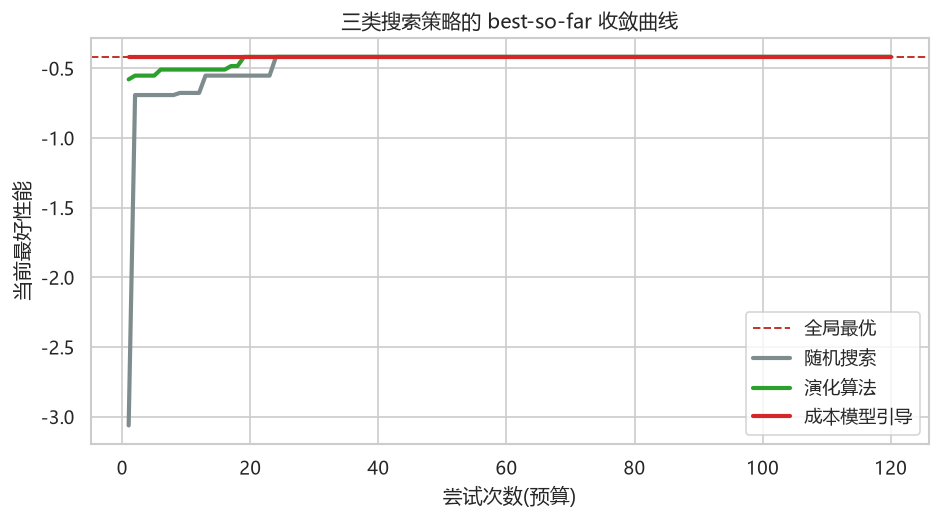

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {"随机搜索": "#7f8c8d", "演化算法": "#2ca02c", "成本模型引导": "#d62728"}
ax.axhline(global_best, ls="--", color="#c0392b", lw=1.2, label="全局最优")
for name, c in curves.items():
    ax.plot(range(1, budget + 1), c, lw=2.5, color=colors[name], label=name)
ax.set_xlabel("尝试次数(预算)"); ax.set_ylabel("当前最好性能")
ax.set_title("三类搜索策略的 best-so-far 收敛曲线")
ax.legend(); plt.tight_layout()

## 4️⃣ torch.compile 实测:max-autotune 模式 🚀

PyTorch 的 `torch.compile` 也内置了自动调优:mode=`max-autotune` 会**在编译时对每个 kernel
搜索 Triton 配置**(tile/warp/stage),而默认模式用启发式直接选。我们用一个小 MLP 实测
三种方案:eager、compile(default)、compile(max-autotune):

⚠️ 诚实说明:小模型在小 GPU 上编译未必更快(max-autotune 本身也花编译时间);真实收益在更大模型、更吃算力的算子上才明显。

In [7]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(256, 512); self.fc2 = nn.Linear(512, 256)
    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))

m = MLP().cuda().eval(); x = torch.randn(64, 256, device="cuda")

def bench(fn, n=40):
    with torch.no_grad():
        for _ in range(8): fn()
        torch.cuda.synchronize(); s = torch.cuda.Event(True); e = torch.cuda.Event(True); s.record()
        for _ in range(n): fn()
        e.record(); torch.cuda.synchronize(); return s.elapsed_time(e) / n

eager_ms = bench(lambda: m(x))
rows = [{"mode": "eager", "compile_s": 0.0, "ms": eager_ms}]
for mode in ["default", "max-autotune"]:
    t0 = time.perf_counter()
    cf = torch.compile(m, mode=mode)
    with torch.no_grad(): cf(x)
    cs = time.perf_counter() - t0
    rows.append({"mode": mode, "compile_s": round(cs, 1), "ms": bench(lambda: cf(x))})
rdf = pd.DataFrame(rows)
print(rdf.to_string(index=False))

        mode  compile_s       ms
       eager        0.0 0.120682
     default        3.8 0.083799
max-autotune        0.1 0.084599


📊 柱状图对比三种模式的单次推理耗时;同时留意『编译耗时』是运行时之外的一次性成本。

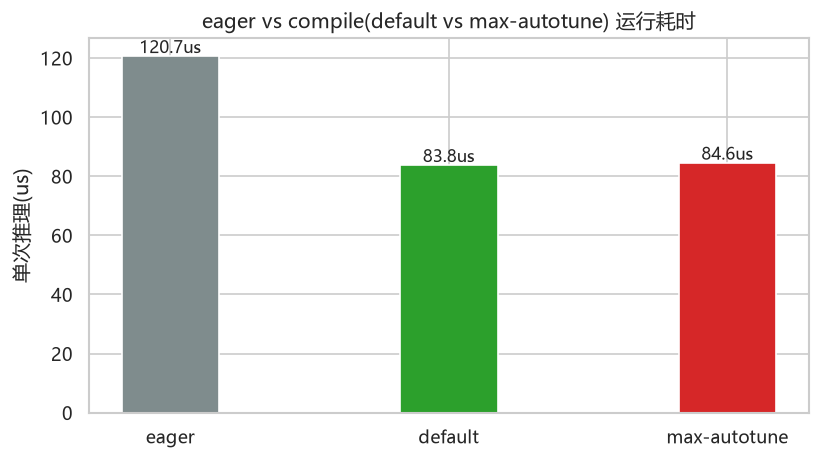

In [8]:
# 编译时间 vs 运行时间的可视化
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(rdf)); w = 0.35
ms = rdf["ms"].values * 1000
ax.bar(x, ms, w, color=["#7f8c8d", "#2ca02c", "#d62728"])
ax.set_xticks(x); ax.set_xticklabels(rdf["mode"])
for i, v in enumerate(ms):
    ax.text(i, v + 1, f"{v:.1f}us", ha="center", fontsize=10)
ax.set_ylabel("单次推理(us)"); ax.set_title("eager vs compile(default vs max-autotune) 运行耗时")
plt.tight_layout()

## 5️⃣ 配套 App:搜索策略交互 🎛️

同目录的 `app_65_autotune.py` 把搜索策略做成交互:选**随机 / 演化 / 成本模型**、拨**预算**,
实时看 best-so-far 收敛曲线与性能地形:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_65_autotune.py
```

浏览器打开 **http://localhost:8501**。建议把预算从 10 拖到 200,对比不同策略的收敛速度。
完整源码如下:

📜 运行本 cell 覆盖写入 `app_65_autotune.py`,保证 notebook 与 app 一致。

In [9]:
%%writefile app_65_autotune.py
# -*- coding: utf-8 -*-
# app_65_autotune.py — 自动调优:搜索策略交互 🎯
import streamlit as st
import plotly.graph_objects as go
import numpy as np

st.set_page_config(page_title="自动调优 🎯", layout="wide")
st.title("🎯 第 65 课 · 自动调优:搜索策略交互")

st.markdown("""
同一段计算(比如矩阵乘)有**海量实现方式**:分块大小、线程数、流水线级数不同,性能天差地别。
**自动调优(auto-tuning)** 就是让编译器自己搜出最优配置:要么**穷举/随机**试,要么用**演化算法**,
要么靠**成本模型**猜一个方向再微调。下方选一种策略、拨预算,看『最好的那版』随搜索次数如何收敛。
""")

rng = np.random.default_rng(0)
# ---------------- 合成"性能地形"(更小的 tile 通常更快,但有个最优谷) ----------------
BM = np.arange(16, 145, 8)
BK = np.arange(8, 81, 8)
BMM, BKK = np.meshgrid(BM, BK)
# 地形:中心偏左下有个最优;远离则变差(带噪声)
perf = -((BMM - 80) ** 2 / 4000 + (BKK - 40) ** 2 / 900) - 0.5 + rng.normal(0, 0.08, BMM.shape)
flat = perf.ravel()
idx = np.arange(len(flat))

# ---------------- 三种搜索策略 ----------------
def random_search(budget, rng):
    picks = rng.choice(idx, budget, replace=False)
    best = max(flat[p] for p in picks)
    curve = np.maximum.accumulate([flat[p] for p in picks])
    return curve, best

def evolutionary(budget, rng, pop=20):
    best_curve, best = [], -np.inf
    pop_idx = rng.choice(idx, pop, replace=False)
    fit = np.array([flat[p] for p in pop_idx])
    for step in range(budget):
        b = max(fit); best = max(best, b); best_curve.append(best)
        keep = pop_idx[np.argsort(fit)[-pop // 2:]]
        children = []
        for k in keep:
            child = int(np.clip(k + rng.normal(0, 6), 0, len(idx) - 1))
            children.append(child)
        pop_idx = np.concatenate([keep, children])
        fit = np.array([flat[p] for p in pop_idx])
    return np.array(best_curve), best

def cost_model(budget, rng):
    best_curve, best = [], -np.inf
    # 从性能地形中心偏优的位置起步,每次沿梯度方向微调(用局部爬山近似"成本模型引导")
    cur = int(np.argmax(flat))
    for step in range(budget):
        b = flat[cur]; best = max(best, b); best_curve.append(best)
        nbrs = [cur + 1, cur - 1, cur + len(BM), cur - len(BM)]
        nbrs = [n for n in nbrs if 0 <= n < len(idx)]
        nxt = max(nbrs, key=lambda n: flat[n])
        if flat[nxt] <= b:      # 局部最优,随机跳一下(模拟退火式)
            cur = int(rng.integers(0, len(idx)))
        else:
            cur = nxt
    return np.array(best_curve), best

st.sidebar.header("🎛️ 参数")
strategy = st.sidebar.selectbox("搜索策略", ["成本模型引导", "演化算法", "随机搜索"])
budget = st.sidebar.slider("搜索预算(尝试次数)", 10, 200, 80, 10)
show_landscape = st.sidebar.checkbox("显示性能地形", value=True)
st.sidebar.caption("成本模型像『有地图的人』,演化像『一代代变异择优』,随机像『盲人摸象』。")

if strategy == "随机搜索":
    curve, best = random_search(budget, rng)
elif strategy == "演化算法":
    curve, best = evolutionary(budget, rng)
else:
    curve, best = cost_model(budget, rng)

c1, c2, c3 = st.columns(3)
c1.metric("找到的最优值", f"{best:.2f}")
c2.metric("搜索预算", budget)
c3.metric("相对全局最优", f"{100 * (best / flat.max()):.1f}%")
st.caption(f"当前策略:{strategy}。理论上限(全局最优)= {flat.max():.2f}")

# ---------------- 收敛曲线 ----------------
st.subheader("📈 收敛曲线:最好的解随尝试次数提升")
fig = go.Figure()
fig.add_hline(y=flat.max(), line_dash="dash", line_color="#c0392b",
              annotation_text="全局最优", annotation_position="top left")
fig.add_trace(go.Scatter(x=list(range(1, len(curve) + 1)), y=curve, mode="lines",
                         name=strategy, line=dict(width=3, color="#1f77b4"),
                         fill="tozeroy", fillcolor="rgba(31,119,180,0.15)"))
fig.update_layout(title=f"{strategy} 的 best-so-far 曲线", xaxis_title="尝试次数", yaxis_title="当前最好性能",
                  height=380, margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig, use_container_width=True)
st.caption("⭐ 曲线越早接近全局最优,策略越高效。成本模型通常起步就接近最优,但可能停在局部最优。")

# ---------------- 性能地形 ----------------
if show_landscape:
    st.subheader("🗺️ 性能地形(BM × BK,亮=快)")
    fig2 = go.Figure(go.Heatmap(z=perf, x=BM, y=BK, colorscale="Viridis",
                                hovertemplate="BM=%{x}, BK=%{y}<br>性能=%{z:.2f}<extra></extra>"))
    fig2.update_layout(title="tile 配置的性能地形(合成数据)", xaxis_title="BM(行块)", yaxis_title="BK(K 块)",
                       height=420, margin=dict(l=10, r=10, t=50, b=10))
    st.plotly_chart(fig2, use_container_width=True)

st.markdown("""
> 💡 **结论**:自动调优就是在"性能地形"上爬山。穷举最稳但慢,随机省事但笨,演化会变异择优,
> 成本模型有先验方向但可能陷进局部最优 —— 真实编译器(TVM Ansor / Triton autotune)常混合多种策略。
""")

Overwriting app_65_autotune.py


## ✅ 本课小结

- 自动调优 = 在『性能地形』上搜索最优实现配置;同一运算不同配置性能可差数倍
- 搜索空间高维:GEMM 的 tile / warp / stage 等组合起来是天文数字,不可能全试
- 三类策略:随机(稳但慢)、演化(会探索、稳步逼近)、成本模型(起步快但可能陷局部最优)
- Ansor / Halide autoscheduler / Triton autotune 都是『成本模型 + 搜索』混合体
- torch.compile 的 max-autotune 模式在编译时搜 Triton 配置;小模型未必赚,大算子才明显

## ✍️ 动手练习

1. 把 GEMM 的 tile 配置再扩大一档(如 256 或加 num_warps),补进热力图,看性能地形更细的轮廓
2. 给演化算法加『变异率』参数,画不同变异率下的收敛曲线,观察过小/过大各自的问题
3. 在更大规模的 GEMM(如 4096³)上重跑 max-autotune,看它是否比 default 更快、编译时间多花多少
4. 思考:为什么成本模型『猜错方向』会陷进局部最优?给成本模型加一个『偶尔随机跳』的退火如何改善?

## 🔗 延伸阅读

- [Ansor 论文](https://arxiv.org/abs/2006.06762)
- [Halide autoscheduler](https://people.csail.mit.edu/nickolai/papers/ragan-kelley-halide.pdf)
- [Triton autotune](https://triton-lang.org/)
- [torch.compile modes](https://pytorch.org/docs/stable/generated/torch.compile.html)

---
> 🎉 恭喜完成本课!下一课见!